In [1]:
import os
import sys
from dotenv import load_dotenv

sys.path.append(os.path.abspath(".."))
load_dotenv("../.env")

from scripts.db_connect import get_database

In [ ]:
from sqlalchemy import create_engine
import pandas as pd

engine = create_engine(os.getenv("DATABASE_URL"))

query = """
SELECT
    cl.chat_id,
    cl.prompt,
    cl.response,
    kb.descricao,
    kb.eixo_tematico,
    kb.topico,
    kb.tags,
    s.session_id,
    cl.created_at
FROM
    chat_logs cl
    inner join public.sessions s on cl.session_id = s.session_id
    inner join chat_logs_kb clk on cl.chat_id = clk.chat_id
    inner join knowledge_base kb on clk.kb_id = kb.kb_id
-- WHERE (SELECT id FROM public.sessions ORDER BY id DESC limit 1) = s.id
ORDER BY cl.created_at DESC
"""

df = pd.read_sql_query(query, engine)
df.head()

,chat_id,prompt,response,descricao,eixo_tematico,topico,tags,session_id,created_at
0,110,hey vox,Olá! Tudo bem? Que alegria te ver por aqui! 🌈\...,O projeto Vox utiliza inteligência artificial ...,Sobre o Vox,O Projeto,"[ia, assistente virtual, vox, tecnologia, inov...",407d4334-9ed0-412e-b7a6-04f7d46f41ff,2026-06-05 02:03:01.448147+00:00
1,110,hey vox,Olá! Tudo bem? Que alegria te ver por aqui! 🌈\...,Feiras populares e ambulantes LGBTQIA+ relatam...,Sociedade e Ativismo,Mercado de Trabalho,"[trabalho informal, economia solidária, ambula...",407d4334-9ed0-412e-b7a6-04f7d46f41ff,2026-06-05 02:03:01.448147+00:00
2,110,hey vox,Olá! Tudo bem? Que alegria te ver por aqui! 🌈\...,O assistente prioriza acessibilidade digital e...,Sobre o Vox,Acessibilidade,"[acessibilidade, inclusão digital, gratuito, d...",407d4334-9ed0-412e-b7a6-04f7d46f41ff,2026-06-05 02:03:01.448147+00:00
3,110,hey vox,Olá! Tudo bem? Que alegria te ver por aqui! 🌈\...,N/A,N/A,N/A,None,407d4334-9ed0-412e-b7a6-04f7d46f41ff,2026-06-05 02:03:01.448147+00:00
4,110,hey vox,Olá! Tudo bem? Que alegria te ver por aqui! 🌈\...,A base de conhecimento do Vox reúne fontes aca...,Sobre o Vox,Transparência,"[fontes, dados confiáveis, curadoria, segurança]",407d4334-9ed0-412e-b7a6-04f7d46f41ff,2026-06-05 02:03:01.448147+00:00


In [3]:
print(f"Total de interações gravadas: {df.shape[0]}")                                  
df.info()

Total de interações gravadas: 199
<class 'pandas.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   chat_id        199 non-null    int64              
 1   prompt         199 non-null    str                
 2   response       199 non-null    str                
 3   descricao      199 non-null    str                
 4   eixo_tematico  199 non-null    str                
 5   topico         199 non-null    str                
 6   tags           193 non-null    object             
 7   session_id     199 non-null    str                
 8   created_at     199 non-null    datetime64[us, UTC]
dtypes: datetime64[us, UTC](1), int64(1), object(1), str(6)
memory usage: 14.1+ KB


In [4]:
taxa_rag = df['topico'].notna().mean() * 100                                           
print(f"Taxa de ativação do RAG: {taxa_rag:.2f}%") 

Taxa de ativação do RAG: 100.00%


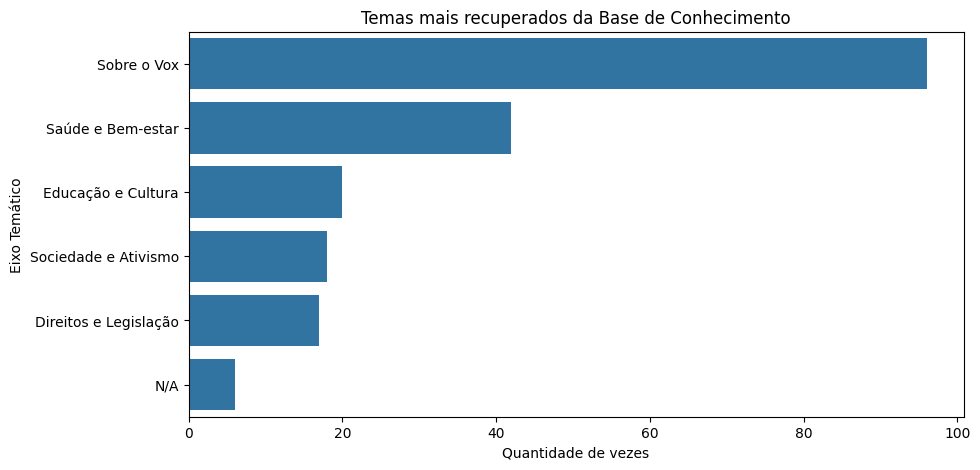

In [5]:
import seaborn as sns                                                                  
import matplotlib.pyplot as plt                                                        
                                                                                       
# Conta os temas e plota                                                               
plt.figure(figsize=(10, 5))                                                            
sns.countplot(data=df, y='eixo_tematico', order=df['eixo_tematico'].value_counts().index)
plt.title("Temas mais recuperados da Base de Conhecimento")
plt.xlabel("Quantidade de vezes")
plt.ylabel("Eixo Temático")
plt.show()